In [1]:
import os

print(os.listdir("/kaggle/input"))

['models', 'datasets']


In [2]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 64.3 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=a68ccac756b3cd5c39f6d7868e3da6e329f826983bb6cd7f589a269ed3bd4919
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [3]:
#imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn

from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import timm

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [4]:
#device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [5]:
#Dataset Loading

DATA_DIR = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

metadata_path = f"{DATA_DIR}/HAM10000_metadata.csv"

image_dir_1 = f"{DATA_DIR}/HAM10000_images_part_1"
image_dir_2 = f"{DATA_DIR}/HAM10000_images_part_2"

df = pd.read_csv(metadata_path)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [6]:
#image path mapping

image_paths = {}

for folder in [image_dir_1, image_dir_2]:

    for img in os.listdir(folder):

        image_id = img.split(".")[0]

        image_paths[image_id] = os.path.join(folder, img)

df["image_path"] = df["image_id"].map(image_paths)

In [7]:
#Label Encoding + Splits

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["dx"])

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

class_names = label_encoder.classes_

print(class_names)

['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


In [8]:
#Select One Melanoma Image

melanoma_df = test_df[
    test_df["dx"] == "mel"
]

print(melanoma_df.head())

sample_image_path = melanoma_df.iloc[0]["image_path"]

print("\nSelected Image Path:")
print(sample_image_path)

        lesion_id      image_id   dx dx_type   age     sex     localization  \
2125  HAM_0007070  ISIC_0032192  mel   histo  80.0    male  lower extremity   
1259  HAM_0005555  ISIC_0032079  mel   histo  60.0  female            chest   
2302  HAM_0003504  ISIC_0028075  mel   histo  55.0    male             face   
1359  HAM_0005084  ISIC_0027261  mel   histo  75.0    male              ear   
2097  HAM_0001397  ISIC_0026796  mel   histo  70.0    male             back   

                                             image_path  label  
2125  /kaggle/input/datasets/kmader/skin-cancer-mnis...      4  
1259  /kaggle/input/datasets/kmader/skin-cancer-mnis...      4  
2302  /kaggle/input/datasets/kmader/skin-cancer-mnis...      4  
1359  /kaggle/input/datasets/kmader/skin-cancer-mnis...      4  
2097  /kaggle/input/datasets/kmader/skin-cancer-mnis...      4  

Selected Image Path:
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2/ISIC_0032192.jpg


In [9]:
#transform

IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

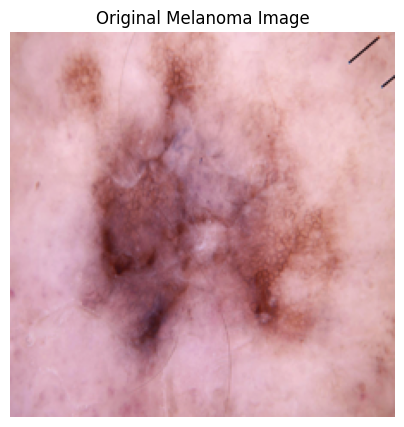

In [10]:
#image loding

image = Image.open(sample_image_path).convert("RGB")

rgb_image = np.array(image.resize((224, 224))) / 255.0

input_tensor = transform(image).unsqueeze(0).to(device)

plt.figure(figsize=(5, 5))
plt.imshow(rgb_image)
plt.title("Original Melanoma Image")
plt.axis("off")
plt.show()

In [13]:
#Load MobileViT Baseline Model

mobilevit_model = timm.create_model(
    "mobilevit_s",
    pretrained=False,
    num_classes=7
)

mobilevit_model.load_state_dict(
    torch.load(
        "/kaggle/input/models/sudhanshukandekar/lightweight-vit-skin-cancer-models-new/pytorch/default/1/02_best_model.pth",
        map_location=device
    )
)

mobilevit_model.to(device)
mobilevit_model.eval()

ByobNet(
  (stem): ConvNormAct(
    (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
  )
  (stages): Sequential(
    (0): Sequential(
      (0): BottleneckBlock(
        (conv1_1x1): ConvNormAct(
          (conv): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
        )
        (conv2_kxk): ConvNormAct(
          (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
          (bn): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
   

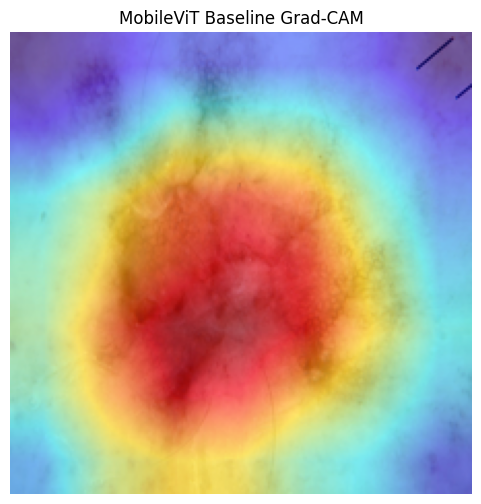

In [14]:
#MobileViT Grad-CAM

target_layers = [mobilevit_model.stages[-1]]

cam = GradCAM(
    model=mobilevit_model,
    target_layers=target_layers
)

targets = [ClassifierOutputTarget(4)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0, :]

mobilevit_visualization = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(6, 6))
plt.imshow(mobilevit_visualization)
plt.title("MobileViT Baseline Grad-CAM")
plt.axis("off")
plt.show()

In [15]:
#Load Weighted CE Model

weighted_model = timm.create_model(
    "mobilevit_s",
    pretrained=False,
    num_classes=7
)

weighted_model.load_state_dict(
    torch.load(
        "/kaggle/input/models/sudhanshukandekar/lightweight-vit-skin-cancer-models-new/pytorch/default/1/03_weighted_loss_best_model.pth",
        map_location=device
    )
)

weighted_model.to(device)

weighted_model.eval()

ByobNet(
  (stem): ConvNormAct(
    (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
  )
  (stages): Sequential(
    (0): Sequential(
      (0): BottleneckBlock(
        (conv1_1x1): ConvNormAct(
          (conv): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
        )
        (conv2_kxk): ConvNormAct(
          (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
          (bn): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
   

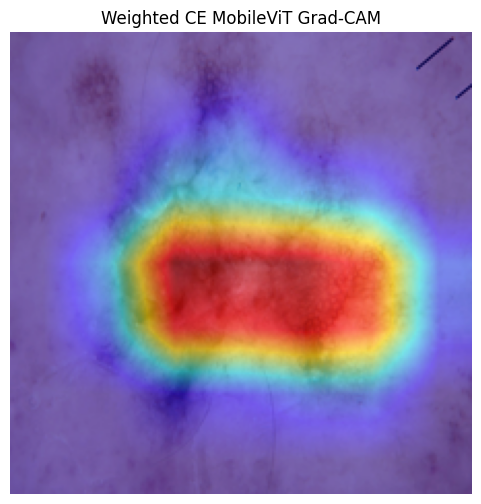

In [16]:
#Weighted CE Grad-CAM

target_layers = [weighted_model.stages[-1]]

cam = GradCAM(
    model=weighted_model,
    target_layers=target_layers
)

targets = [ClassifierOutputTarget(4)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0, :]

weighted_visualization = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(6, 6))

plt.imshow(weighted_visualization)

plt.title("Weighted CE MobileViT Grad-CAM")

plt.axis("off")

plt.show()

In [17]:
#Load CB Loss Model

cb_model = timm.create_model(
    "mobilevit_s",
    pretrained=False,
    num_classes=7
)

cb_model.load_state_dict(
    torch.load(
        "/kaggle/input/models/sudhanshukandekar/lightweight-vit-skin-cancer-models-new/pytorch/default/1/cb_loss_best_model.pth",
        map_location=device
    )
)

cb_model.to(device)
cb_model.eval()

ByobNet(
  (stem): ConvNormAct(
    (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
  )
  (stages): Sequential(
    (0): Sequential(
      (0): BottleneckBlock(
        (conv1_1x1): ConvNormAct(
          (conv): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
        )
        (conv2_kxk): ConvNormAct(
          (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
          (bn): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
   

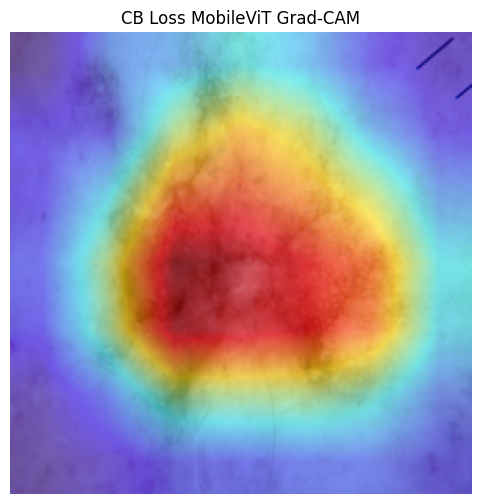

In [18]:
#CB Loss Grad-CAM

target_layers = [cb_model.stages[-1]]

cam = GradCAM(
    model=cb_model,
    target_layers=target_layers
)

targets = [ClassifierOutputTarget(4)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0, :]

cb_visualization = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(6, 6))
plt.imshow(cb_visualization)
plt.title("CB Loss MobileViT Grad-CAM")
plt.axis("off")
plt.show()

In [22]:
#Load TinyViT Model

tinyvit_model = timm.create_model(
    "tiny_vit_5m_224",
    pretrained=False,
    num_classes=7
)

tinyvit_model.load_state_dict(
    torch.load(
        "/kaggle/input/models/sudhanshukandekar/lightweight-vit-skin-cancer-models-new/pytorch/default/1/tinyvit_best_model.pth",
        map_location=device
    )
)

tinyvit_model.to(device)
tinyvit_model.eval()

TinyVit(
  (patch_embed): PatchEmbed(
    (conv1): ConvNorm(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (act): GELU(approximate='none')
    (conv2): ConvNorm(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (stages): Sequential(
    (0): ConvLayer(
      (blocks): Sequential(
        (0): MBConv(
          (conv1): ConvNorm(
            (conv): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (act1): GELU(approximate='none')
          (conv2): ConvNorm(
            (conv): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=256, bias=Fals

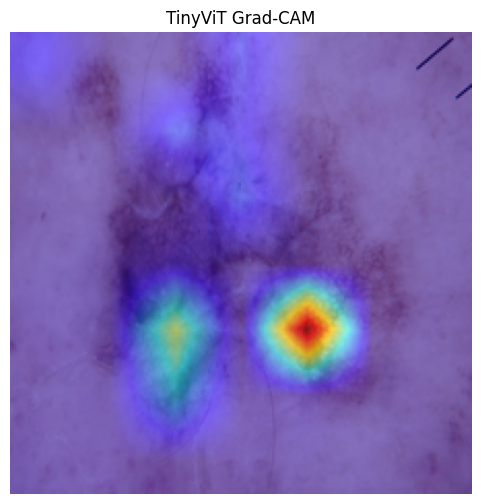

In [23]:

#TinyViT Grad-CAM

target_layers = [tinyvit_model.stages[-1].downsample]

cam = GradCAM(
    model=tinyvit_model,
    target_layers=target_layers
)

targets = [ClassifierOutputTarget(4)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0, :]

tinyvit_visualization = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(6, 6))

plt.imshow(tinyvit_visualization)

plt.title("TinyViT Grad-CAM")

plt.axis("off")

plt.show()

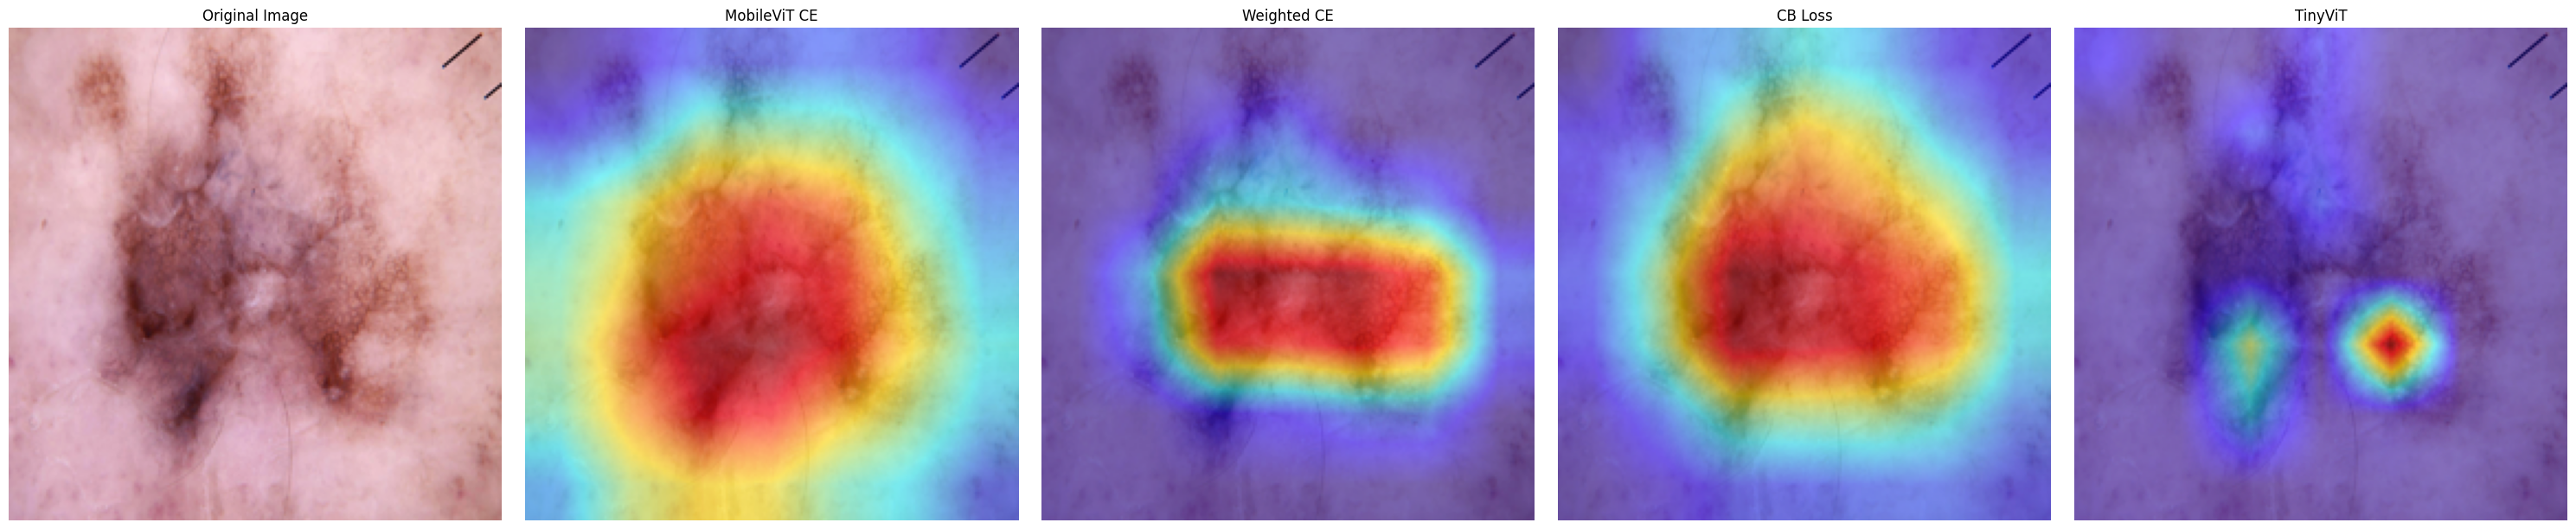

Attention comparison figure saved successfully.


In [24]:
fig, axes = plt.subplots(1, 5, figsize=(30, 6))

axes[0].imshow(rgb_image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(mobilevit_visualization)
axes[1].set_title("MobileViT CE")
axes[1].axis("off")

axes[2].imshow(weighted_visualization)
axes[2].set_title("Weighted CE")
axes[2].axis("off")

axes[3].imshow(cb_visualization)
axes[3].set_title("CB Loss")
axes[3].axis("off")

axes[4].imshow(tinyvit_visualization)
axes[4].set_title("TinyViT")
axes[4].axis("off")

plt.tight_layout()

fig.savefig(
    "attention_comparison.png",
    bbox_inches='tight',
    dpi=300
)

plt.show()

plt.close(fig)

print("Attention comparison figure saved successfully.")

In [25]:
import os

os.makedirs("outputs/attention_visualization/figures", exist_ok=True)

os.makedirs("outputs/attention_visualization/reports", exist_ok=True)


fig.savefig(
    "outputs/attention_visualization/figures/attention_comparison.png",
    bbox_inches='tight',
    dpi=300
)


attention_report = """
Attention Visualization Analysis

1. MobileViT Baseline CE
- Produced broad and diffuse attention maps.
- Attention spread across lesion and background regions.

2. Weighted Cross Entropy
- Generated weak and unstable activation patterns.
- Lesion localization was less interpretable.

3. CB Loss
- Produced stronger lesion-focused activation.
- Improved localization around clinically relevant regions.

4. TinyViT
- Generated sharp and compact lesion attention.
- Minimized irrelevant background activation.

Conclusion
Imbalance-aware learning and lightweight transformer architecture selection influence lesion localization behavior in melanoma classification.
CB Loss improved lesion-centric attention patterns, while TinyViT demonstrated the sharpest localization behavior.
"""


with open(
    "outputs/attention_visualization/reports/attention_analysis_report.txt",
    "w"
) as f:

    f.write(attention_report)


print("Attention comparison figure saved successfully.")

print("Attention analysis report saved successfully.")

Attention comparison figure saved successfully.
Attention analysis report saved successfully.
